In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
import os

In [24]:
train_time_file = "../remote_data/training_timings.log"
eval_metrics_dir = "../remote_data/eval_metrics"

In [14]:
def classify_epoch(x):
    if "," not in x:
        return x
    numbers = [int(y) for y in x.split(",")]
    mx = max(numbers)
    cnt = [y < mx//2 for y in numbers].count(True)
    if cnt > 1:
        return "Exp-dec"
    else:
        return "Exp-inc"

In [15]:
train_time_df = pd.read_csv(train_time_file, names = ["Epoch", "Time"])
train_time_df["cluster_freq"] = train_time_df["Epoch"].apply(classify_epoch)
train_time_df.head()

,Epoch,Time,cluster_freq
0,201,2666.886554,201
1,181,2811.468102,181
2,161,2822.490001,161
3,141,2812.856905,141
4,121,2853.219709,121


In [21]:
import re

epoch_pattern = re.compile(r"step_([\d,]+).*")

In [35]:
data = {
    "model": [],
    "epoch": [],
    "train_loss": [],
    "train_top1": [],
    "train_top5": [],
    "test_top1": [],
    "test_top5": []
}

for file in os.listdir(eval_metrics_dir):
    df = pd.read_csv(os.path.join(eval_metrics_dir, file), header=0)
    base = os.path.basename(file)
    epoch_number = epoch_pattern.match(base).group(1) 
    epoch_type = classify_epoch(epoch_number)

    for idx, row in df.iterrows():
        data["model"].append(epoch_type)
        data["epoch"].append(row["epoch"])
        data["train_loss"].append(row["train_loss"])
        data["train_top1"].append(row["train_top1"])
        data["train_top5"].append(row["train_top5"])
        data["test_top1"].append(row["test_top1"])
        data["test_top5"].append(row["test_top5"])

stats_df = pd.DataFrame(data)

<Axes: xlabel='epoch', ylabel='test_top1'>

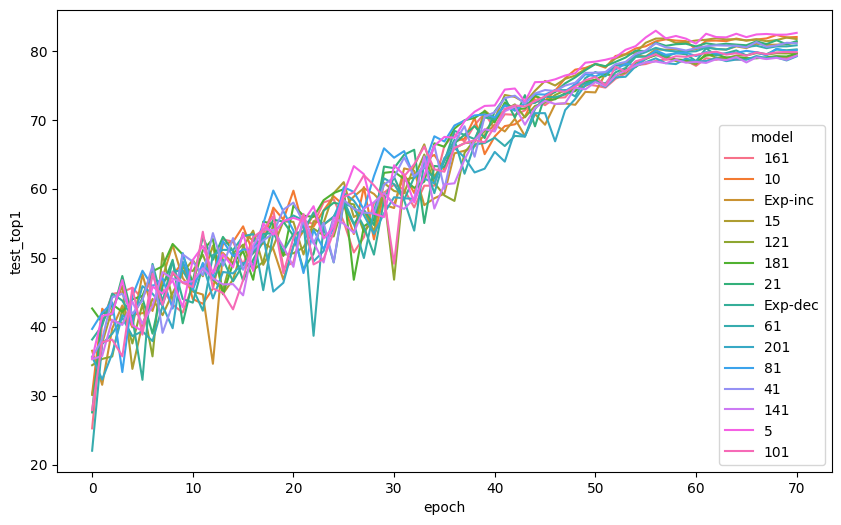

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(stats_df[stats_df["epoch"] <= 70], x="epoch", y="test_top1", hue="model")

<Axes: xlabel='epoch', ylabel='train_loss'>

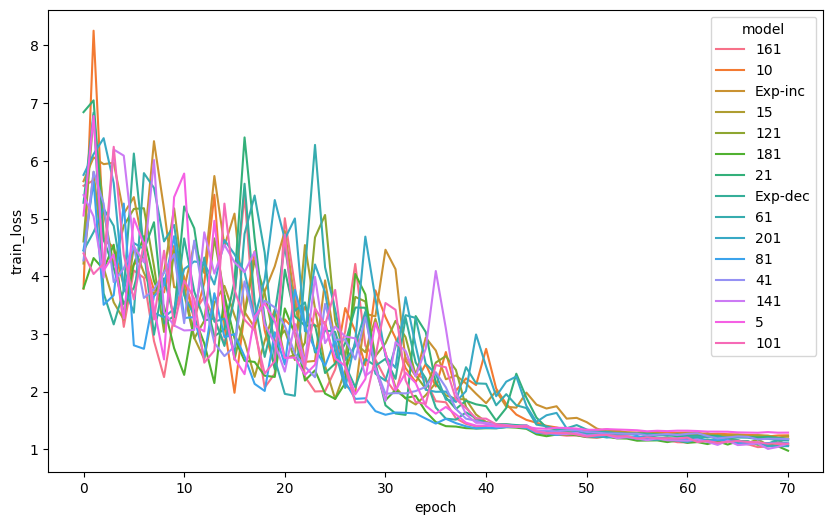

In [ ]:
plt.figure(figsize=(10, 6))
sns.lineplot(stats_df[stats_df["epoch"] <= 70], x="epoch", y="train_loss", hue="model")